# Wine Quality Prediction with Engineered Features

**Author:** Kavinda Pushpa Kumara | Food Science Student | IBM Certified Data Scientist

**Goal:** Build a classifier to identify *premium* red wines (quality score ≥ 7) using a small set of chemically meaningful engineered features, rather than throwing all raw measurements at the model.

**Why feature engineering?**  
Raw lab measurements (pH, alcohol %, sulphates, etc.) are useful individually, but they often capture more signal when combined into ratios or products that match how winemakers actually think about quality — body, aroma complexity, acidity balance, and preservation.

**Dataset:** UCI Wine Quality – Red Wine  
Source: P. Cortez et al., 2009. *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems.

---
**Notebook outline**
1. Load & explore the data
2. Engineer 5 domain-informed features
3. Feature selection analysis (correlation + importance)
4. Build a baseline model (sanity check)
5. Train optimised Random Forest with correct SMOTE + CV pipeline
6. Evaluate and compare against raw features
7. Reusable prediction function

## 1. Setup

In [ ]:
# imbalanced-learn
!pip install imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, accuracy_score,
    precision_recall_curve, average_precision_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   # supports SMOTE inside CV

import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

print('Libraries loaded')

Libraries loaded


## 2. Load & Explore the Data

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print('Shape:', df.shape)
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# quick look at data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
# check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


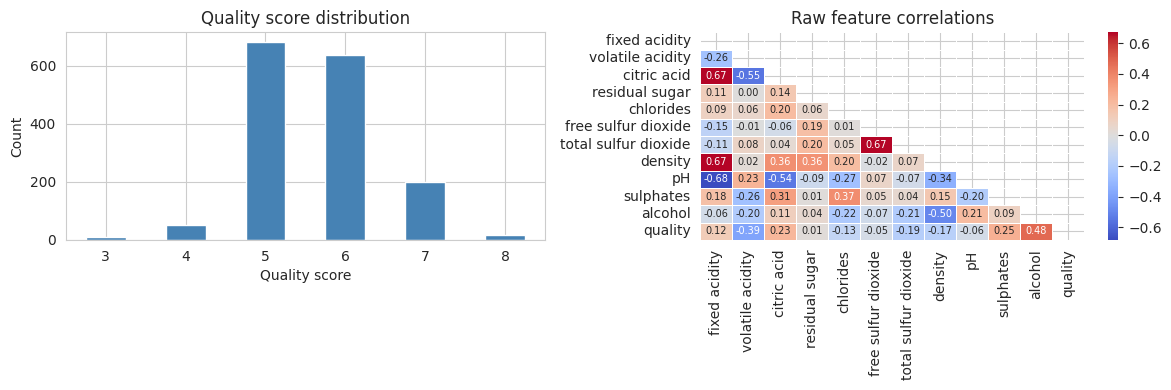

In [ ]:
# quality score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Quality score distribution')
axes[0].set_xlabel('Quality score')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# correlation heatmap of raw features
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Raw feature correlations')

plt.tight_layout()
plt.show()

In [ ]:
# define binary target: premium = quality >= 7
df['is_premium'] = (df['quality'] >= 7).astype(int)

print('Class distribution:')
print(df['is_premium'].value_counts())
print(f"\nPremium wines: {df['is_premium'].mean()*100:.1f}% of dataset")
print('\n=> Class imbalance is significant — will need to address this during training')

Class distribution:
is_premium
0    1382
1     217
Name: count, dtype: int64

Premium wines: 13.6% of dataset

=> Class imbalance is significant — will need to address this during training


## 3. Feature Engineering

Instead of using all 11 raw measurements, I want to engineer features that capture winemaking concepts directly.  
Each feature below is grounded in food science:

| Feature | Formula | What it captures |
|---|---|---|
| `alcohol_density_ratio` | alcohol ÷ density | Body & mouthfeel — higher alcohol relative to density = fuller body |
| `flavor_intensity` | sulphates × alcohol | Aroma richness — sulphates support aromatic complexity; alcohol extracts volatile compounds |
| `acidity_quality` | pH × volatile acidity | Acidity balance — penalises wines with high volatile acidity (vinegar/acetic off-flavours) |
| `sugar_acid_balance` | residual sugar ÷ fixed acidity | Sweetness perception — important for palate balance in dry reds |
| `so2_efficiency` | free SO₂ ÷ alcohol | Preservation efficiency — normalises SO₂ level relative to alcohol content |

**Note on `sugar_acid_balance`:** its correlation with quality is weak (≈ −0.03), but it is included because sweetness-acidity balance is a fundamental winemaking concept. It may still provide interaction effects in tree-based models even when its marginal correlation is low.

**References:** Peynaud, E. (1987). *Knowing and Making Wine*. Wiley; OIV Standards for volatile acidity limits.

In [ ]:
df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['flavor_intensity']      = df['sulphates'] * df['alcohol']
df['acidity_quality']       = df['pH'] * df['volatile acidity']
df['sugar_acid_balance']    = df['residual sugar'] / (df['fixed acidity'] + 0.001)
df['so2_efficiency']        = df['free sulfur dioxide'] / (df['alcohol'] + 0.001)

engineered_features = [
    'alcohol_density_ratio',
    'flavor_intensity',
    'acidity_quality',
    'sugar_acid_balance',
    'so2_efficiency'
]

df[engineered_features].describe()

,alcohol_density_ratio,flavor_intensity,acidity_quality,sugar_acid_balance,so2_efficiency
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,10.458047,6.876770,1.754164,0.313995,1.544815
std,1.080202,1.925061,0.622483,0.183987,1.043953
min,8.393285,3.003000,0.409200,0.112486,0.097078
25%,9.534324,5.489000,1.282350,0.231570,0.730369
50%,10.203061,6.468000,1.727800,0.272692,1.304206
75%,11.136975,7.838000,2.132600,0.330842,2.093283
max,14.935846,19.404000,5.530000,2.481700,6.989613


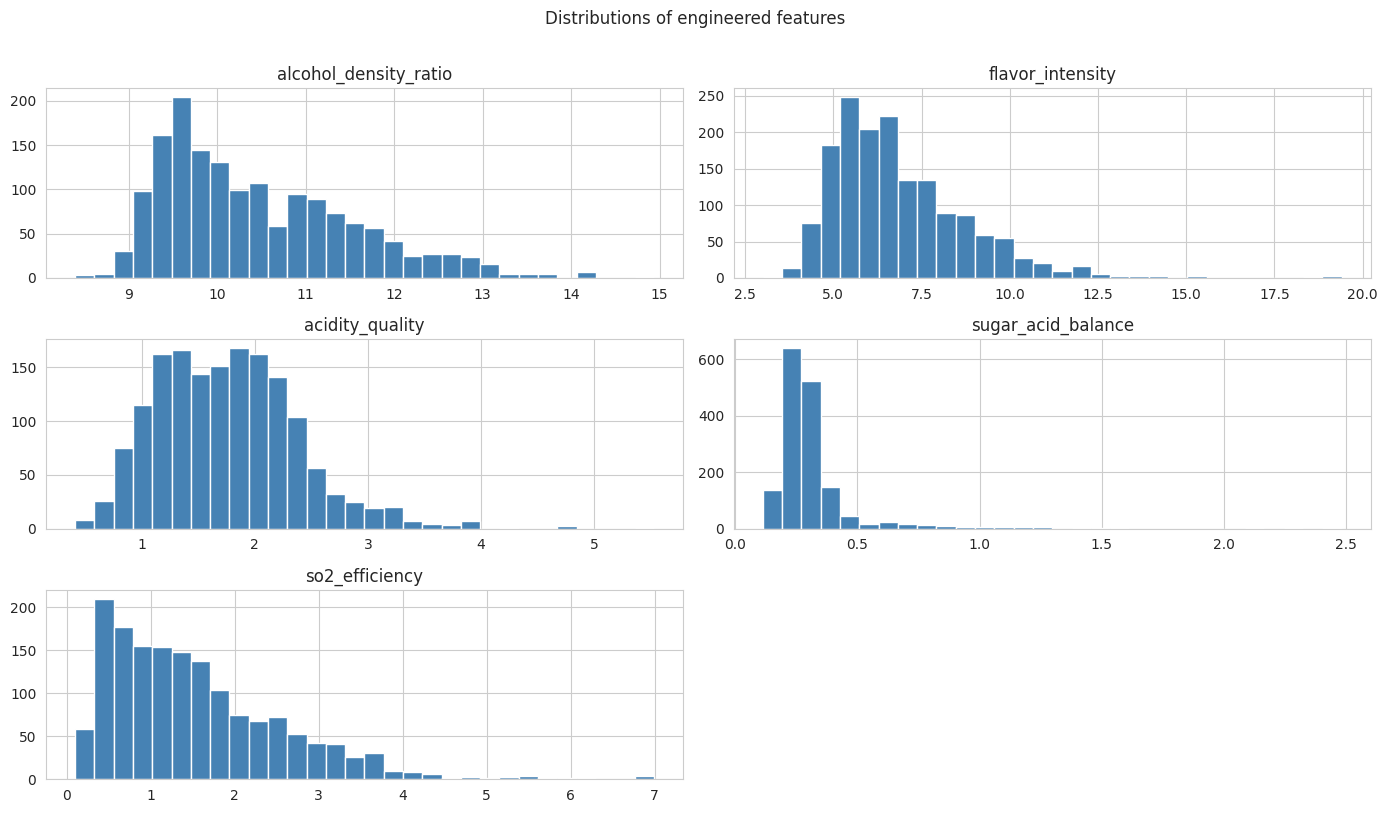

In [ ]:
# look at distributions of the new features
df[engineered_features].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distributions of engineered features', y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Selection Analysis

**Important:** all feature selection analysis below is done on the *training split only*, to avoid peeking at the test set.

We look at:
- Pearson correlation with the quality score
- Random Forest feature importances
- Diminishing returns: how many features do we actually need?

In [ ]:
# split FIRST, then do all analysis on training data only
X_all = df[engineered_features].copy()
y     = df['is_premium'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Train premium rate: {y_train.mean()*100:.1f}%  |  Test premium rate: {y_test.mean()*100:.1f}%')

Train: 1279 samples  |  Test: 320 samples
Train premium rate: 13.6%  |  Test premium rate: 13.4%


In [ ]:
# correlation of engineered features vs raw components — training set only
train_df = X_train.copy()
train_df['quality'] = df.loc[X_train.index, 'quality']

# also bring in raw components for comparison
raw_components = ['alcohol', 'density', 'sulphates', 'pH',
                  'volatile acidity', 'residual sugar', 'fixed acidity', 'free sulfur dioxide']
for col in raw_components:
    train_df[col] = df.loc[X_train.index, col]

eng_corr = train_df[engineered_features].corrwith(train_df['quality'])
raw_corr = train_df[raw_components].corrwith(train_df['quality'])

print('Engineered feature correlations with quality (training set):')
print(eng_corr.sort_values(key=abs, ascending=False).to_string())
print('\nRaw feature correlations with quality (training set):')
print(raw_corr.sort_values(key=abs, ascending=False).to_string())

Engineered feature correlations with quality (training set):
alcohol_density_ratio    0.467147
flavor_intensity         0.391358
acidity_quality         -0.373090
so2_efficiency          -0.132201
sugar_acid_balance      -0.014118

Raw feature correlations with quality (training set):
alcohol                0.468255
volatile acidity      -0.383268
sulphates              0.228191
density               -0.175768
fixed acidity          0.110115
free sulfur dioxide   -0.065791
pH                    -0.042573
residual sugar         0.024635


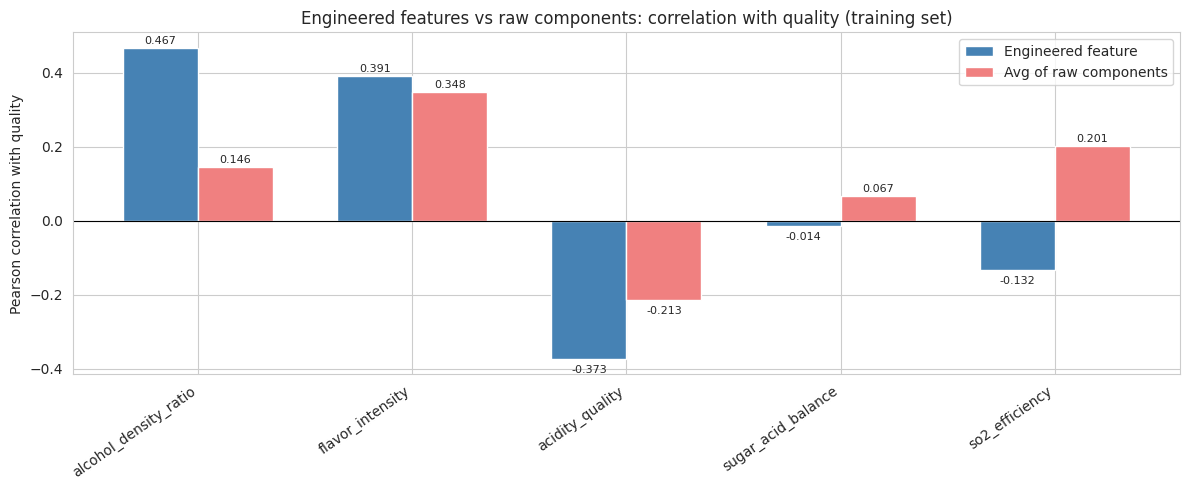

In [ ]:
# comparison plot: engineered vs average of their raw components
component_map = {
    'alcohol_density_ratio': ['alcohol', 'density'],
    'flavor_intensity':      ['sulphates', 'alcohol'],
    'acidity_quality':       ['pH', 'volatile acidity'],
    'sugar_acid_balance':    ['residual sugar', 'fixed acidity'],
    'so2_efficiency':        ['free sulfur dioxide', 'alcohol'],
}

rows = []
for feat, comps in component_map.items():
    e_corr = train_df[feat].corr(train_df['quality'])
    r_corr = train_df[comps].corrwith(train_df['quality']).mean()
    rows.append({'Feature': feat, 'Engineered': e_corr, 'Avg raw': r_corr})

cmp_df = pd.DataFrame(rows)

x = np.arange(len(cmp_df))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, cmp_df['Engineered'], w, label='Engineered feature', color='steelblue')
b2 = ax.bar(x + w/2, cmp_df['Avg raw'],    w, label='Avg of raw components', color='lightcoral')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cmp_df['Feature'], rotation=35, ha='right')
ax.set_ylabel('Pearson correlation with quality')
ax.set_title('Engineered features vs raw components: correlation with quality (training set)')
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3 if h >= 0 else -10), textcoords='offset points',
                ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# quick RF to get feature importances — trained on training set only
scaler_imp = StandardScaler()
X_tr_imp   = scaler_imp.fit_transform(X_train)

# use SMOTE here too to match the real training setup
sm_imp = SMOTE(random_state=RANDOM_STATE)
X_tr_imp_bal, y_tr_imp_bal = sm_imp.fit_resample(X_tr_imp, y_train)

rf_imp = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)
rf_imp.fit(X_tr_imp_bal, y_tr_imp_bal)

imp_df = pd.DataFrame({
    'feature':    engineered_features,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature importances (from training set RF):')
print(imp_df.to_string(index=False))

Feature importances (from training set RF):
              feature  importance
alcohol_density_ratio    0.300665
     flavor_intensity    0.285175
      acidity_quality    0.177338
       so2_efficiency    0.125637
   sugar_acid_balance    0.111185


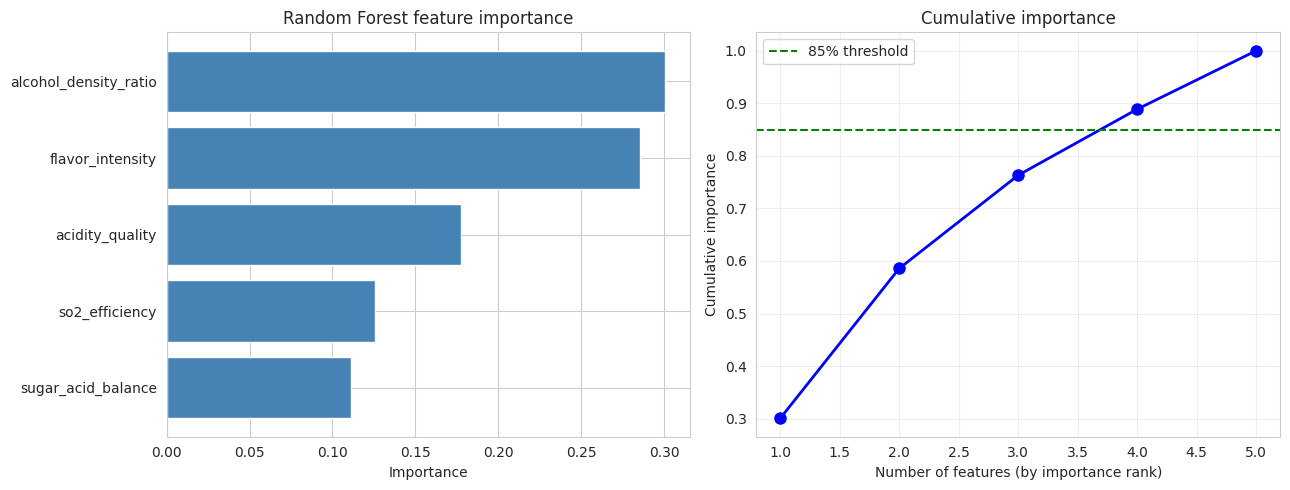

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(imp_df['feature'], imp_df['importance'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest feature importance')

cum_imp = imp_df['importance'].cumsum().values
axes[1].plot(range(1, len(imp_df)+1), cum_imp, 'bo-', lw=2, markersize=8)
axes[1].axhline(0.85, color='green', linestyle='--', label='85% threshold')
axes[1].set_xlabel('Number of features (by importance rank)')
axes[1].set_ylabel('Cumulative importance')
axes[1].set_title('Cumulative importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# diminishing returns: how does F1 change as we add more features?
# using an imblearn Pipeline so SMOTE only runs inside each CV fold — avoids data leakage

sorted_features = imp_df['feature'].tolist()   # ordered by importance

dim_results = []
for n in range(1, len(sorted_features) + 1):
    top_n = sorted_features[:n]
    X_sub  = X_train[top_n]

    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                          random_state=RANDOM_STATE))
    ])

    cv_f1 = cross_val_score(pipe, X_sub, y_train, cv=5, scoring='f1', n_jobs=-1)
    dim_results.append({'n_features': n, 'mean_f1': cv_f1.mean(), 'std_f1': cv_f1.std()})

dim_df = pd.DataFrame(dim_results)
print('Diminishing returns analysis (5-fold CV on training set):')
print(dim_df.to_string(index=False))

Diminishing returns analysis (5-fold CV on training set):
 n_features  mean_f1   std_f1
          1 0.442433 0.031401
          2 0.491982 0.034419
          3 0.560614 0.020028
          4 0.552574 0.041973
          5 0.581432 0.035773


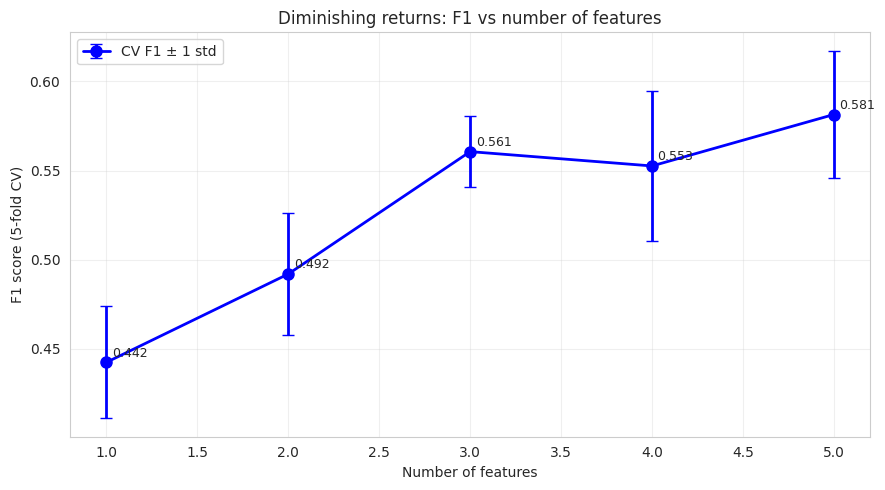

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(dim_df['n_features'], dim_df['mean_f1'],
            yerr=dim_df['std_f1'], fmt='bo-', lw=2, markersize=8,
            capsize=4, label='CV F1 ± 1 std')

# annotate each point
for _, row in dim_df.iterrows():
    ax.annotate(f"{row['mean_f1']:.3f}",
                xy=(row['n_features'], row['mean_f1']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Number of features')
ax.set_ylabel('F1 score (5-fold CV)')
ax.set_title('Diminishing returns: F1 vs number of features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Distribution Analysis: Premium vs Non-Premium

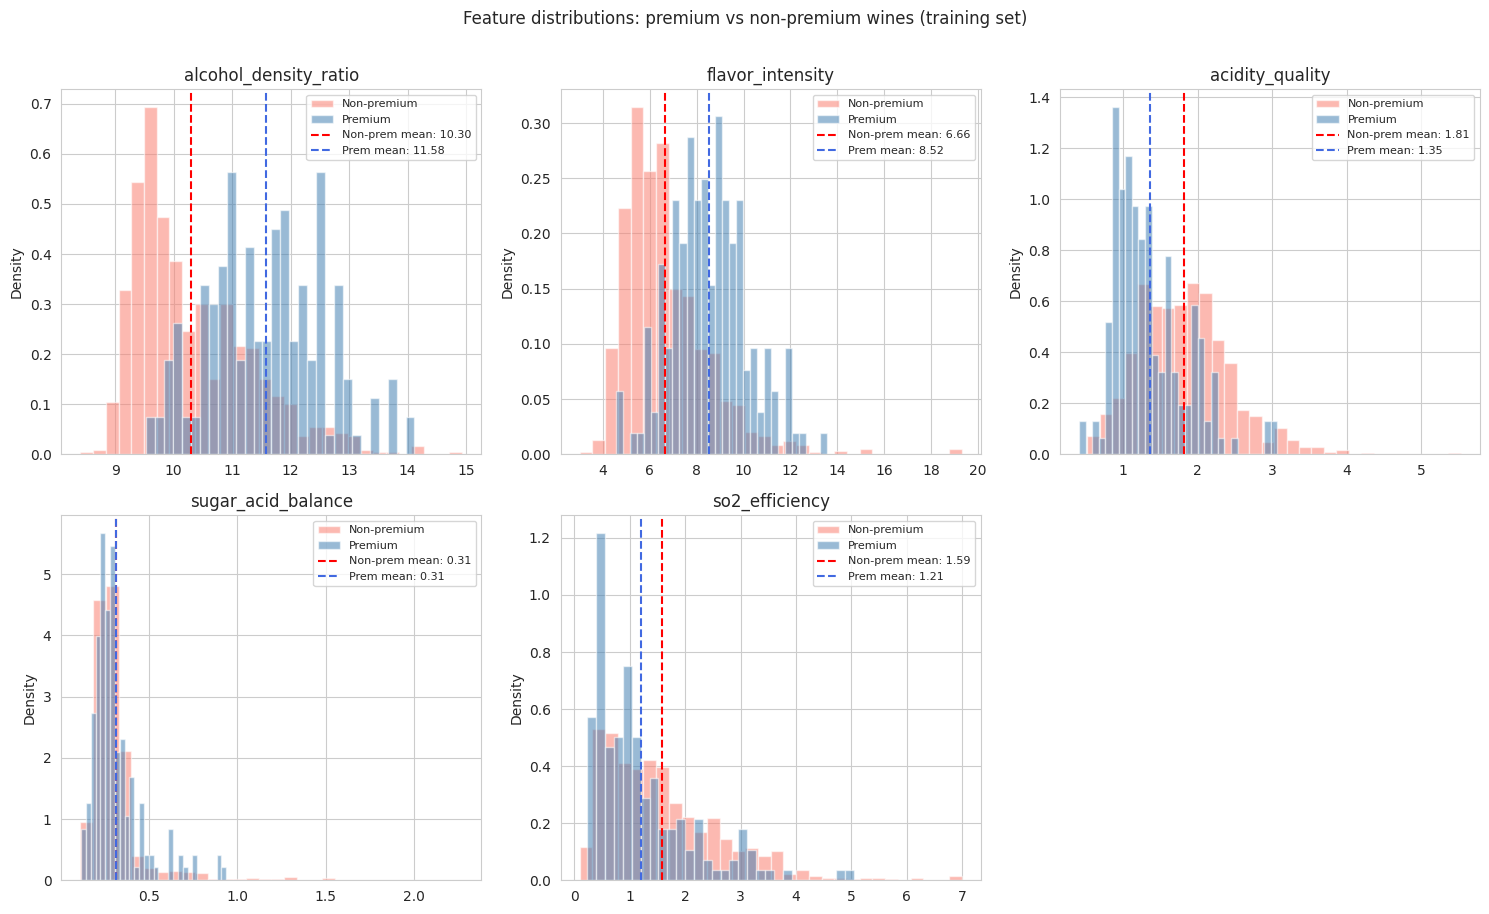

In [ ]:
# visualise how each engineered feature separates the two classes
# using training set only

train_plot = X_train.copy()
train_plot['is_premium'] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(engineered_features):
    premium     = train_plot[train_plot['is_premium'] == 1][feat]
    non_premium = train_plot[train_plot['is_premium'] == 0][feat]

    axes[i].hist(non_premium, bins=30, alpha=0.55, label='Non-premium', color='salmon',   density=True)
    axes[i].hist(premium,     bins=30, alpha=0.55, label='Premium',     color='steelblue', density=True)
    axes[i].axvline(non_premium.mean(), color='red',       linestyle='--', linewidth=1.5, label=f'Non-prem mean: {non_premium.mean():.2f}')
    axes[i].axvline(premium.mean(),     color='royalblue', linestyle='--', linewidth=1.5, label=f'Prem mean: {premium.mean():.2f}')
    axes[i].set_title(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

fig.delaxes(axes[5])
plt.suptitle('Feature distributions: premium vs non-premium wines (training set)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Baseline Model

Before training a proper model, let's see what a trivial classifier achieves.  
This sets the floor — our actual model must clearly beat this.

In [ ]:
# DummyClassifier: always predicts the majority class (Non-premium)
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('=== Baseline (always predicts Non-Premium) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}')
print()


=== Baseline (always predicts Non-Premium) ===
Accuracy : 0.8656
F1       : 0.0000



Our model must significantly exceed these numbers to be useful.
High accuracy can be misleading when classes are imbalanced!

## 7. Train the Main Model

**Key design decisions:**
- `ImbPipeline` from `imblearn` ensures SMOTE is applied *inside* each cross-validation fold, so synthetic samples from the training fold never leak into the validation fold.
- `StandardScaler` is also inside the pipeline, so scaling is always fit on the training fold only.
- `class_weight='balanced'` in the RF adds a second layer of imbalance handling.

In [ ]:
# build the pipeline
pipe_main = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

# hyperparameter grid — prefix with 'clf__' to target the RF step
param_grid = {
    'clf__n_estimators':    [100, 200, 300],
    'clf__max_depth':       [8, 10, 12, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4],
}

grid = GridSearchCV(
    pipe_main, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)

print('Running grid search... (this may take a couple of minutes)')
grid.fit(X_train, y_train)

print(f'\nBest params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

Running grid search... (this may take a couple of minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params : {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV F1  : 0.5891


In [ ]:
# refit best pipeline and run cross-validation to get a stable estimate
best_pipe = grid.best_estimator_

cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'5-fold CV F1 scores : {cv_scores}')
print(f'Mean ± 2·std        : {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}')

5-fold CV F1 scores : [0.56470588 0.6        0.55       0.62790698 0.60273973]
Mean ± 2·std        : 0.5891 ± 0.0561


## 8. Evaluate on the Held-Out Test Set

In [ ]:
y_pred  = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
ap  = average_precision_score(y_test, y_proba)

print('=== Test set performance (5 engineered features) ===')
print(f'Accuracy         : {acc:.4f}')
print(f'F1 (Premium)     : {f1:.4f}')
print(f'AUC-ROC          : {auc:.4f}')
print(f'Avg Precision    : {ap:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-Premium', 'Premium']))

=== Test set performance (5 engineered features) ===
Accuracy         : 0.9156
F1 (Premium)     : 0.7097
AUC-ROC          : 0.9511
Avg Precision    : 0.8277

              precision    recall  f1-score   support

 Non-Premium       0.96      0.94      0.95       277
     Premium       0.66      0.77      0.71        43

    accuracy                           0.92       320
   macro avg       0.81      0.85      0.83       320
weighted avg       0.92      0.92      0.92       320



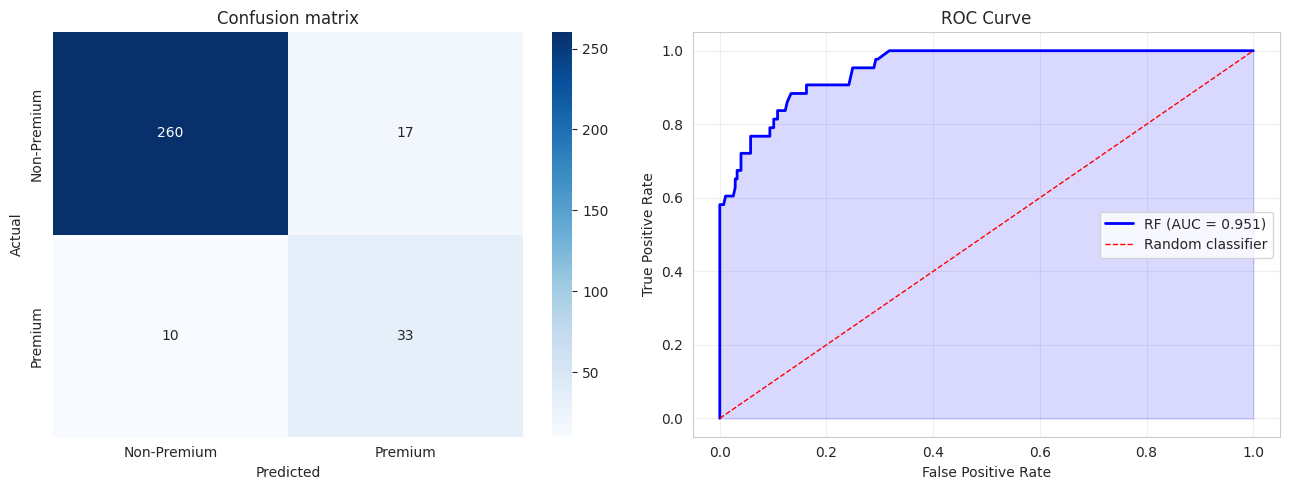

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Premium', 'Premium'],
            yticklabels=['Non-Premium', 'Premium'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'RF (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='blue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8a. Precision-Recall Trade-off

For a winery use case, false positives (labelling an ordinary wine as premium) and false negatives (missing a genuinely premium wine) have very different costs:

- **False positive** → a standard wine gets premium pricing → customer dissatisfaction, brand damage
- **False negative** → a premium wine is sold as standard → lost revenue

Depending on business priorities, the classification threshold of 0.5 may not be optimal.  
The precision-recall curve below helps choose a threshold that balances these trade-offs.

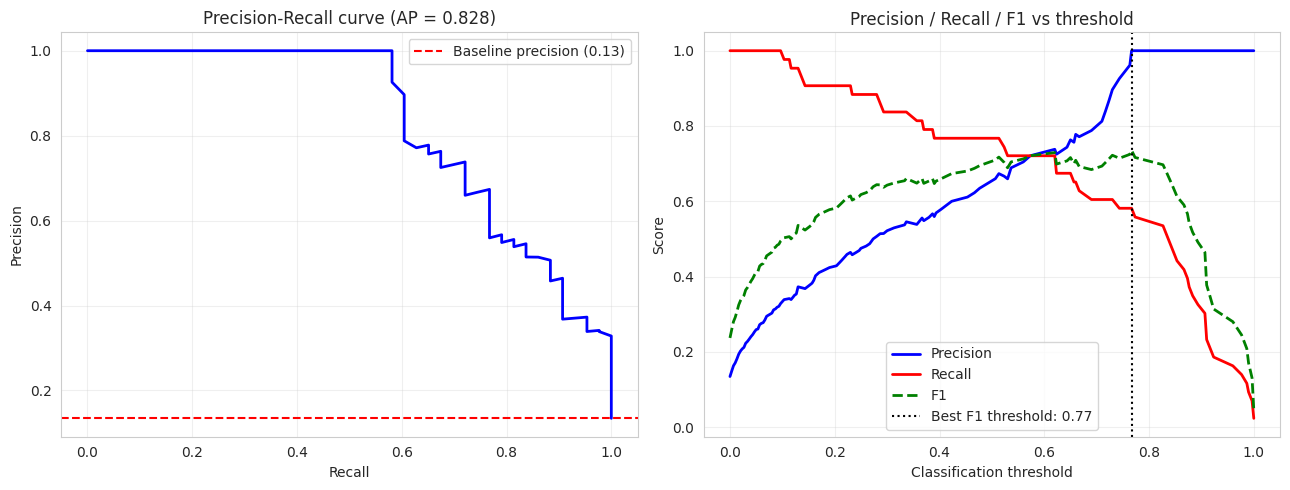

Optimal threshold for F1: 0.767
Adjust this depending on business priorities (higher threshold = higher precision, lower recall)


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# precision-recall curve
axes[0].plot(recall, precision, 'b-', lw=2)
axes[0].axhline(y_test.mean(), color='red', linestyle='--', label=f'Baseline precision ({y_test.mean():.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve (AP = {ap:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 vs threshold
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_thresh     = thresholds[best_thresh_idx]

axes[1].plot(thresholds, precision[:-1], 'b-',  lw=2, label='Precision')
axes[1].plot(thresholds, recall[:-1],    'r-',  lw=2, label='Recall')
axes[1].plot(thresholds, f1_scores,      'g--', lw=2, label='F1')
axes[1].axvline(best_thresh, color='black', linestyle=':', label=f'Best F1 threshold: {best_thresh:.2f}')
axes[1].set_xlabel('Classification threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Optimal threshold for F1: {best_thresh:.3f}')

## 9. Comparison: Engineered Features vs Raw Features

To justify the feature engineering effort, let's compare our 5 engineered features against a model that uses the 5 most correlated *raw* features.

In [ ]:
# select 5 raw features most correlated with quality (from training set)
raw_all   = df[raw_components].copy()
raw_all['quality'] = df['quality']
raw_train = raw_all.loc[X_train.index]

top_raw = raw_train.drop(columns='quality').corrwith(raw_train['quality']).abs().sort_values(ascending=False).head(5).index.tolist()
print('Top 5 raw features by correlation with quality (training set):', top_raw)

X_train_raw = df.loc[X_train.index, top_raw]
X_test_raw  = df.loc[X_test.index,  top_raw]

pipe_raw = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=RANDOM_STATE)),
    ('clf',    RandomForestClassifier(n_estimators=200, max_depth=10,
                                      class_weight='balanced', random_state=RANDOM_STATE))
])

pipe_raw.fit(X_train_raw, y_train)
y_pred_raw  = pipe_raw.predict(X_test_raw)
y_proba_raw = pipe_raw.predict_proba(X_test_raw)[:, 1]

print()
print('=== Raw features model performance ===')
print(classification_report(y_test, y_pred_raw, target_names=['Non-Premium', 'Premium']))

Top 5 raw features by correlation with quality (training set): ['alcohol', 'volatile acidity', 'sulphates', 'density', 'fixed acidity']

=== Raw features model performance ===
              precision    recall  f1-score   support

 Non-Premium       0.97      0.91      0.94       277
     Premium       0.59      0.81      0.69        43

    accuracy                           0.90       320
   macro avg       0.78      0.86      0.81       320
weighted avg       0.92      0.90      0.91       320



      Metric  Engineered (5)  Raw (5)
    Accuracy        0.915625 0.900000
F1 (Premium)        0.709677 0.686275
     AUC-ROC        0.951138 0.926538


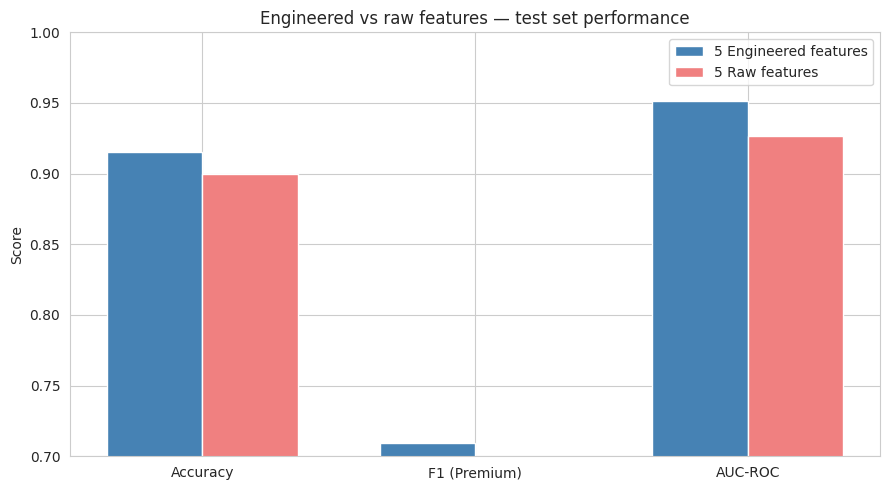

In [ ]:
# side-by-side summary
metrics = ['Accuracy', 'F1 (Premium)', 'AUC-ROC']
eng_vals = [acc, f1, auc]
raw_vals = [
    accuracy_score(y_test, y_pred_raw),
    f1_score(y_test, y_pred_raw),
    roc_auc_score(y_test, y_proba_raw)
]

cmp = pd.DataFrame({'Metric': metrics, 'Engineered (5)': eng_vals, 'Raw (5)': raw_vals})
print(cmp.to_string(index=False))

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, eng_vals, w, label='5 Engineered features', color='steelblue')
ax.bar(x + w/2, raw_vals, w, label='5 Raw features',        color='lightcoral')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Engineered vs raw features — test set performance')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Prediction Function

A clean function that takes raw wine measurements, engineers the features internally, and returns a prediction with food science interpretation.

In [ ]:
def predict_wine_quality(alcohol, density, sulphates, pH, volatile_acidity,
                          residual_sugar, fixed_acidity, free_sulfur_dioxide,
                          threshold=0.5):
    """
    Predict whether a red wine is premium (quality >= 7).

    Parameters
    ----------
    alcohol              : float  — % vol
    density              : float  — g/cm³
    sulphates            : float  — g/dm³ (potassium sulphate)
    pH                   : float
    volatile_acidity     : float  — g/dm³ (acetic acid)
    residual_sugar       : float  — g/dm³
    fixed_acidity        : float  — g/dm³
    free_sulfur_dioxide  : float  — mg/dm³
    threshold            : float  — classification threshold (default 0.5)

    Returns
    -------
    dict with prediction, probability, engineered feature values, and notes
    """
    # engineer features
    feat_vals = {
        'alcohol_density_ratio': alcohol / density,
        'flavor_intensity':      sulphates * alcohol,
        'acidity_quality':       pH * volatile_acidity,
        'sugar_acid_balance':    residual_sugar / (fixed_acidity + 1e-6),
        'so2_efficiency':        free_sulfur_dioxide / (alcohol + 1e-6),
    }

    input_df = pd.DataFrame([feat_vals])
    prob     = best_pipe.predict_proba(input_df)[0, 1]
    label    = 'Premium' if prob >= threshold else 'Non-Premium'

    # food science notes
    notes = []
    if feat_vals['alcohol_density_ratio'] > 12.5:
        notes.append('Full-bodied (high alcohol-density ratio)')
    elif feat_vals['alcohol_density_ratio'] < 11.5:
        notes.append('Light-bodied (low alcohol-density ratio)')

    if feat_vals['flavor_intensity'] > 9:
        notes.append('High aroma complexity (good sulphates x alcohol)')
    elif feat_vals['flavor_intensity'] < 6:
        notes.append('Low flavor intensity — may lack complexity')

    if feat_vals['acidity_quality'] < 2.0:
        notes.append('Clean acidity balance')
    elif feat_vals['acidity_quality'] > 3.0:
        notes.append('High volatile acidity — risk of vinegar off-flavour')

    if 15 <= feat_vals['so2_efficiency'] <= 35:
        notes.append('SO2 in optimal preservation range')
    elif feat_vals['so2_efficiency'] < 15:
        notes.append('Low SO2 — oxidation risk')
    else:
        notes.append('High SO2 — possible over-sulfiting')

    if not notes:
        notes.append('Balanced profile')

    return {
        'prediction':          label,
        'premium_probability': round(float(prob), 3),
        'threshold_used':      threshold,
        'engineered_features': {k: round(v, 4) for k, v in feat_vals.items()},
        'notes':               notes
    }

print('predict_wine_quality() defined')

predict_wine_quality() defined


In [ ]:
# test on a few example wines
examples = [
    {
        'label':             'High-quality red',
        'alcohol':           12.5,
        'density':           0.994,
        'sulphates':         0.95,
        'pH':                3.3,
        'volatile_acidity':  0.35,
        'residual_sugar':    1.8,
        'fixed_acidity':     8.5,
        'free_sulfur_dioxide': 12
    },
    {
        'label':             'Ordinary table wine',
        'alcohol':           9.8,
        'density':           0.997,
        'sulphates':         0.65,
        'pH':                3.5,
        'volatile_acidity':  0.55,
        'residual_sugar':    2.5,
        'fixed_acidity':     7.5,
        'free_sulfur_dioxide': 18
    },
    {
        'label':             'Faulty wine (high volatile acidity)',
        'alcohol':           8.5,
        'density':           0.999,
        'sulphates':         0.45,
        'pH':                3.7,
        'volatile_acidity':  0.85,
        'residual_sugar':    3.5,
        'fixed_acidity':     6.5,
        'free_sulfur_dioxide': 25
    }
]

for wine in examples:
    result = predict_wine_quality(
        alcohol=wine['alcohol'], density=wine['density'],
        sulphates=wine['sulphates'], pH=wine['pH'],
        volatile_acidity=wine['volatile_acidity'],
        residual_sugar=wine['residual_sugar'],
        fixed_acidity=wine['fixed_acidity'],
        free_sulfur_dioxide=wine['free_sulfur_dioxide']
    )
    print(f"--- {wine['label']} ---")
    print(f"  Prediction  : {result['prediction']}  (prob = {result['premium_probability']})")
    print(f"  Notes       : {'; '.join(result['notes'])}")
    print(f"  Eng. values : {result['engineered_features']}")
    print()

--- High-quality red ---
  Prediction  : Premium  (prob = 0.773)
  Notes       : Full-bodied (high alcohol-density ratio); High aroma complexity (good sulphates x alcohol); Clean acidity balance; Low SO2 — oxidation risk
  Eng. values : {'alcohol_density_ratio': 12.5755, 'flavor_intensity': 11.875, 'acidity_quality': 1.155, 'sugar_acid_balance': 0.2118, 'so2_efficiency': 0.96}

--- Ordinary table wine ---
  Prediction  : Non-Premium  (prob = 0.0)
  Notes       : Light-bodied (low alcohol-density ratio); Clean acidity balance; Low SO2 — oxidation risk
  Eng. values : {'alcohol_density_ratio': 9.8295, 'flavor_intensity': 6.37, 'acidity_quality': 1.925, 'sugar_acid_balance': 0.3333, 'so2_efficiency': 1.8367}

--- Faulty wine (high volatile acidity) ---
  Prediction  : Non-Premium  (prob = 0.003)
  Notes       : Light-bodied (low alcohol-density ratio); Low flavor intensity — may lack complexity; High volatile acidity — risk of vinegar off-flavour; Low SO2 — oxidation risk
  Eng. values : 

## 11. Save models

In [ ]:
# Extract the scaler and RF separately from the pipeline

scaler_standalone = best_pipe.named_steps['scaler']
rf_standalone     = best_pipe.named_steps['clf']

joblib.dump(rf_standalone,      'wine_model.pkl')
joblib.dump(scaler_standalone,  'scaler.pkl')
joblib.dump(engineered_features, 'wine_feature_names.pkl')

print('Saved:')
print('  wine_model.pkl          — trained RandomForestClassifier')
print('  scaler.pkl              — fitted StandardScaler')
print('  wine_feature_names.pkl  — list of feature names')

Saved:
  wine_model.pkl          — trained RandomForestClassifier
  scaler.pkl              — fitted StandardScaler
  wine_feature_names.pkl  — list of feature names


## Summary

| | Baseline (majority-class) | Raw features (5) | Engineered features (5) |
|---|---|---|---|
| **Accuracy** | ~86.4% | **90.00%** | **91.56%** |
| **F1 (Premium)** | 0.00 | **0.686** | **0.710** |
| **AUC-ROC** | 0.50 | **0.927** | **0.951** |
|
|

**Key takeaways**

- Accuracy alone is misleading with imbalanced classes (~14% premium). Always check F1 and AUC.
- Engineered features grounded in food science capture more signal than the same number of raw measurements.
- Using `ImbPipeline` with SMOTE *inside* cross-validation folds is essential to avoid inflated CV scores.
- The precision-recall trade-off matters for deployment: a winery may prefer higher precision (don't mislabel ordinary wine as premium) over higher recall, which means raising the classification threshold.
- `sugar_acid_balance` has a near-zero marginal correlation with quality but is retained because sweetness-acidity balance is a fundamental concept in winemaking; its interaction with other features may still be informative for the tree model.

